In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import iris
import cftime
import numpy as np
import xarray_tools as xrt
from notebook_metadata import create_savefig
from pathlib import Path

savefig = create_savefig(dir='/scratch/tm70/mrd599/plots', nb='esm_historical_ozone_check.ipynb')

In [2]:
from dask.distributed import Client
client = Client(threads_per_worker = 1)

In [3]:
area_esm15 = xr.open_dataset('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/piControl/r1i1p1f1/fx/areacella/gn/latest/areacella_fx_ACCESS-ESM1-5_piControl_r1i1p1f1_gn.nc').areacella


In [4]:
# ozone_esm15 = iris.load_cube('/g/data/vk83/configurations/inputs/access-esm1p5/modern/historical/atmosphere/forcing/global.N96/2021.06.22/ozone_1849_2015_ESM1.anc')
# ozone_esm15 = xr.DataArray.from_iris(ozone_esm15).squeeze().rename({'latitude':'lat'})

# ozone_esm16 = iris.load_cube('/g/data/tm70/pcl851/CMIP7/esm1p6_ancil/2026.02.20/modern/historical/forcing/global.N96/2026.02.20/ozone_1849_2023_cmip7.anc')
# ozone_esm16 = xr.DataArray.from_iris(ozone_esm16).squeeze().rename({'latitude':'lat'})

ozone_esm15 = xr.open_dataset('/scratch/tm70/mrd599/ozone_esm15.nc').field60.squeeze()
ozone_esm16 = xr.open_dataset('/scratch/tm70/mrd599/ozone_esm16.nc').field60.squeeze()

/jobfs/161382074.gadi-pbs/ipykernel_3975997/1774121848.py:8: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ozone_esm16 = xr.open_dataset('/scratch/tm70/mrd599/ozone_esm16.nc').field60.squeeze()


In [29]:
print(otmp.coord('time'))

DimCoord :  time / (hours since 1970-01-01 00:00:00, 360_day calendar)
    points: [
        1849-01-15 00:00:00, 1849-02-15 00:00:00, 1849-03-15 00:00:00,
        1849-04-15 00:00:00, 1849-05-15 00:00:00, 1849-06-15 00:00:00,
        1849-07-15 00:00:00, 1849-08-15 00:00:00, 1849-09-15 00:00:00,
        1849-10-15 00:00:00, 1849-11-15 00:00:00, 1849-12-15 00:00:00]
    bounds: [
        [1848-12-30 00:00:00, 1849-01-30 00:00:00],
        [1849-01-30 00:00:00, 1849-02-30 00:00:00],
        ...,
        [1849-10-30 00:00:00, 1849-11-30 00:00:00],
        [1849-11-30 00:00:00, 1849-12-30 00:00:00]]
    shape: (12,)  bounds(12, 2)
    dtype: float64
    standard_name: 'time'


In [22]:
otmp = iris.load_cube('/scratch/tm70/mrd599/ozone_subset')

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/iris/fileformats/_ff.py:737: _WarnComboLoadingDefaulting: The stash code m01s00i060 is on a grid 22 which has not been explicitly handled by the fieldsfile loader. Assuming the data is on a P grid.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/iris/fileformats/rules.py:371: IrisUserWarning: Unable to create instance of HybridHeightFactory. The source data contains no field(s) for 'orography'.
  warnings.warn(


In [5]:
ozone_esm15_a = xrt.annual_mean(ozone_esm15).load()
ozone_esm16_a = xrt.annual_mean(ozone_esm16).load()

Text(0.5, 1.0, 'ESM1.6 annual mean ozone at 80S')

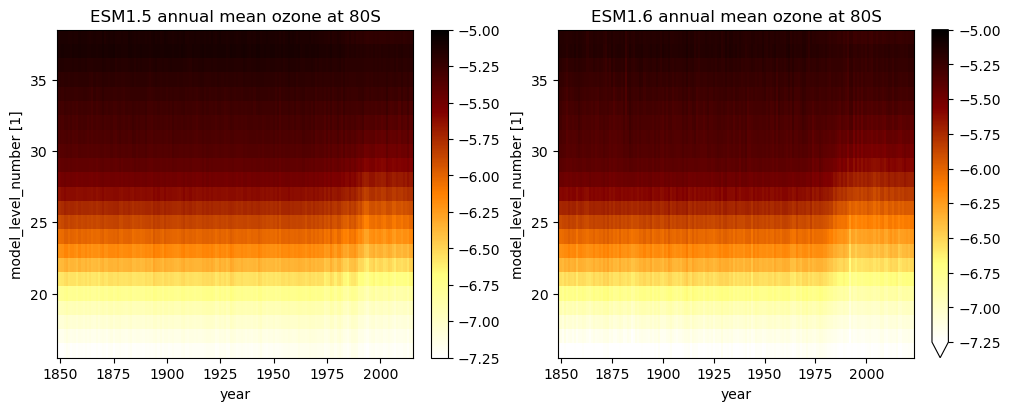

In [9]:
fig, axes = plt.subplots(1,2,layout='constrained',figsize=(10,4))
# axes = axes.flat()
vmin = -7.25
vmax = -5
ax = axes[0]
np.log10(ozone_esm15_a)[:,15:].sel(lat=-80).plot(x='year',ax=ax, vmin=vmin, vmax=vmax, cmap='afmhot_r')
ax.set_title('ESM1.5 annual mean ozone at 80S')
ax = axes[1]
np.log10(ozone_esm16_a)[:,15:].sel(lat=-80).plot(x='year',ax=ax, vmin=vmin, vmax=vmax, cmap='afmhot_r')
ax.set_title('ESM1.6 annual mean ozone at 80S')

Text(0.5, 1.0, 'ESM1.6 September ozone at 80S')

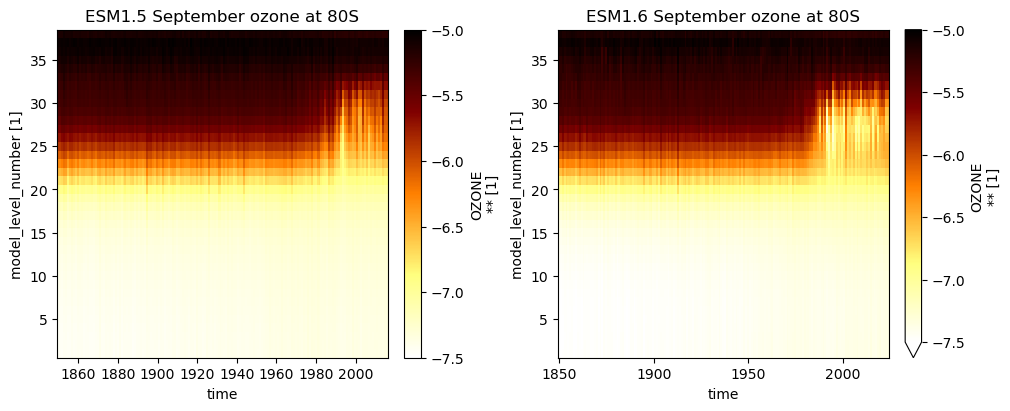

In [ ]:
fig, axes = plt.subplots(1,2,layout='constrained',figsize=(10,4))
# axes = axes.flat()
vmin = -7.5
vmax = -5
ax = axes[0]
np.log10(ozone_esm15)[9::12].sel(lat=-80).plot(x='time',ax=ax, vmin=vmin, vmax=vmax, cmap='afmhot_r')
ax.set_title('ESM1.5 October ozone at 80S')
ax = axes[1]
np.log10(ozone_esm16)[9::12].sel(lat=-80).plot(x='time',ax=ax, vmin=vmin, vmax=vmax, cmap='afmhot_r')
ax.set_title('ESM1.6 October ozone at 80S')

In [19]:
ozone_esm15.time[0]

<xarray.DataArray 'time' ()> Size: 8B
array('1849-01-16T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time          datetime64[ns] 8B 1849-01-16
    lon           float32 4B 360.0
    pseudo_level  int32 4B ...
    realization   int32 4B ...
Attributes:
    axis:           T
    standard_name:  time

In [20]:
ozone_esm16.time[0]

<xarray.DataArray 'time' ()> Size: 8B
array(cftime.Datetime360Day(1849, 1, 15, 0, 0, 0, 0, has_year_zero=True),
      dtype=object)
Coordinates:
    time                     object 8B 1849-01-15 00:00:00
    lon                      float32 4B 180.0
    forecast_period          timedelta64[ns] 8B ...
    forecast_reference_time  object 8B ...
Attributes:
    axis:           T
    bounds:         time_bnds
    standard_name:  time

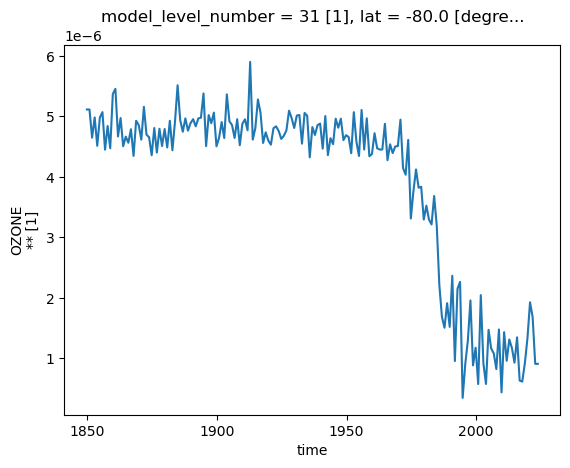

In [15]:
# ozone_esm15[9::12,30].sel(lat=-80).plot()
ozone_esm16[9::12,30].sel(lat=-80).plot()

In [ ]:
ozone_esm15[9::12,30].sel(lat=-80).plot()

In [ ]:
ozone_cmip6 = xr.open_mfdataset('/g/data/qv56/replicas/input4MIPs/CMIP6/CMIP/UReading/UReading-CCMI-1-0/atmos/mon/vmro3/gn/v20160711/vmro3_input4MIPs_ozone_CMIP_UReading-CCMI-1-0_gn_*.nc', decode_times=False).vmro3
ozone_cmip7 = xr.open_mfdataset('/g/data/qv56/replicas/input4MIPs/CMIP7/CMIP/FZJ/FZJ-CMIP-ozone-1-2/atmos/mon/vmro3/gn/v20251025/vmro3_input4MIPs_ozone_CMIP_FZJ-CMIP-ozone-1-2_gn_*.nc').vmro3
# ozone_cmip7x = xr.open_mfdataset('/g/data/qv56/replicas/input4MIPs/CMIP7/CMIP/FZJ/FZJ-CMIP-ozone-1-2/atmos/mon/vmro3/gn/v20251010/vmro3_input4MIPs_ozone_CMIP_FZJ-CMIP-ozone-1-2_gn_*.nc').vmro3

In [ ]:
ozone_cmip7_v2 = xr.open_mfdataset('/scratch/tm70/mrd599/fixed_ozone/vmro3_input4MIPs_ozone_CMIP_FZJ-CMIP-ozone-2-0_gn_*.nc').vmro3

In [ ]:
ozone_cmip7_clim = xr.open_dataset('/g/data/qv56/replicas/input4MIPs/CMIP7/CMIP/FZJ/FZJ-CMIP-ozone-1-2/atmos/monC/vmro3/gn/v20251010/vmro3_input4MIPs_ozone_CMIP_FZJ-CMIP-ozone-1-2_gn_185001-185012-clim.nc').vmro3


In [ ]:
# Time coordinate is months which is non standard. CMIP7 data uses noleap calendar so match that
ny = len(ozone_cmip6) // 12
tvals = []
units = "days since 1850-01-01 00:00"
for y in range(1850, 1850+ny):
    for m in range(1,13):
        t1 = cftime.date2num(cftime.DatetimeNoLeap(y, m, 1), units, "noleap")
        y2 = y
        m2 = m + 1
        if m2==13:
            m2 = 1
            y2 += 1
        t2 = cftime.date2num(cftime.DatetimeNoLeap(y2, m2, 1), units, "noleap")
        tvals.append((t1+t2)/2)
tvals = cftime.num2date(tvals, units, "noleap")

ozone_cmip6 = ozone_cmip6.assign_coords({'time': tvals})

In [ ]:
# Ozone data is VMR. Conversion to MMR factor
conv_factor = 48.0 / 28.966

# Factor for conversion of kg/m^2 to DU from https://sacs.aeronomie.be/info/dobson.php
du_factor = 2.1415e-5

# Mass of each layer
# Midpoint pressures
plev = 100*ozone_cmip7.plev.values  # Pa
pmid = 0.5*(plev[1:] + plev[:-1])
pmidx = np.concatenate(([1e5], pmid, [0.]))
dp = -np.diff(pmidx)
grav = 9.806
dmass = dp / grav

In [ ]:
ozone_mass_cmip6 = conv_factor*(ozone_cmip6*dmass[np.newaxis,:, np.newaxis, np.newaxis]).sum('plev')
ozone_mass_cmip7 = conv_factor*(ozone_cmip7*dmass[np.newaxis,:, np.newaxis, np.newaxis]).sum('plev')

ozone_mass_cmip6_z = ozone_mass_cmip6.mean('lon').compute()
ozone_mass_cmip7_z = ozone_mass_cmip7.mean('lon').compute()

In [ ]:
ozone_mass_cmip7_v2 = conv_factor*(ozone_cmip7_v2*dmass[np.newaxis,:, np.newaxis, np.newaxis]).sum('plev')
ozone_mass_cmip7_v2_z = ozone_mass_cmip7_v2.mean('lon').compute()

In [ ]:
# ozone_mass_cmip7x = conv_factor*(ozone_cmip7x*dmass[np.newaxis,:, np.newaxis, np.newaxis]).sum('plev')
# ozone_mass_cmip7x_z = ozone_mass_cmip7x.mean('lon').compute()

In [ ]:
ozone_mass_cmip7_clim = conv_factor*(ozone_cmip7_clim*dmass[np.newaxis,:, np.newaxis, np.newaxis]).sum('plev')
ozone_mass_cmip7_clim_z = ozone_mass_cmip7_clim.mean('lon').compute()

In [ ]:
fig, axes = plt.subplots(1,2,layout='constrained',figsize=(10,4))
ax = axes[0]
# xrt.annual_mean(ozone_cmip7x[:12]).sel(lat=0,method='nearest').mean('lon').plot(y='plev',yscale='log')
xrt.annual_mean(ozone_cmip7_clim).sel(lat=0,method='nearest').mean('lon').plot(ax=ax, y='plev',yscale='log', label='1850 climatology')
# xrt.annual_mean(ozone_cmip7).sel(year=1849).sel(lat=0,method='nearest').mean('lon').plot(y='plev',yscale='log', label='1849 historical')
xrt.annual_mean(ozone_cmip7).sel(year=1850).sel(lat=0,method='nearest').mean('lon').plot(ax=ax, y='plev',yscale='log', label='1850 historical v1-2')
xrt.annual_mean(ozone_cmip7_v2).sel(year=1850).sel(lat=0,method='nearest').mean('lon').plot(ax=ax, y='plev',yscale='log', label='1850 historical v2-0')
ax.invert_yaxis()
ax.set_ylim(1000,0.01)
ax.legend()
ax.set_xlabel('Ozone VMR')
ax.set_title('CMIP7 1850 ozone at equator')


ax = axes[1]
# (xrt.annual_mean(ozone_mass_cmip6_z).sel(year=1850)/du_factor).plot(label='CMIP6')
(xrt.annual_mean(ozone_mass_cmip7_clim_z)/du_factor).plot(ax=ax, label='1850 climatology')
(xrt.annual_mean(ozone_mass_cmip7_z).sel(year=1850)/du_factor).plot(ax=ax, label='1850 historical v1-2')
# (xrt.annual_mean(ozone_mass_cmip7_z).sel(year=slice(1829,1849)).mean('year')/du_factor).plot(ax=ax, label='1829-1849 mean v1-2')
(xrt.annual_mean(ozone_mass_cmip7_v2_z).sel(year=1850)/du_factor).plot(ax=ax, label='1850 historical v2-0')
ax.legend()
ax.set_title('1850 total column ozone')
ax.set_xlabel('Latitude')
ax.set_xlim(-90,90)
ax.set_xticks(np.linspace(-90,90,7))

ax.set_ylabel('DU')

savefig('cmip7_1850_ozone_v2.png')

In [ ]:
fig, axes = plt.subplots(1,2,layout='constrained',figsize=(10,4))
ax = axes[0]
xrt.annual_mean(ozone_cmip7_clim).sel(lat=0,method='nearest').mean('lon').plot(ax=ax, y='plev',yscale='log', label='1850 climatology v1-2')
xrt.annual_mean(ozone_cmip7).sel(year=slice(1850,1870)).sel(lat=0,method='nearest').mean(('year','lon')).plot(ax=ax, y='plev',yscale='log', label='1850-1870 mean v1-2')
xrt.annual_mean(ozone_cmip7_v2).sel(year=slice(1850,1870)).sel(lat=0,method='nearest').mean(('year','lon')).plot(ax=ax, y='plev',yscale='log', label='1850-1870 mean v2-0')
ax.invert_yaxis()
ax.set_ylim(1000,0.01)
ax.legend()
ax.set_xlabel('Ozone VMR')
ax.set_title('CMIP7 1850-1870 ozone at equator')


ax = axes[1]
(xrt.annual_mean(ozone_mass_cmip7_clim_z)/du_factor).plot(ax=ax, label='1850 climatology v1-2')
(xrt.annual_mean(ozone_mass_cmip7_z).sel(year=slice(1850,1870)).mean('year')/du_factor).plot(ax=ax, label='1850-1870 mean v1-2')
(xrt.annual_mean(ozone_mass_cmip7_v2_z).sel(year=slice(1850,1870)).mean('year')/du_factor).plot(ax=ax, label='1850-1870 mean v2-0')
ax.legend()
ax.set_title('1850-1870 total column ozone')
ax.set_xlabel('Latitude')
ax.set_xlim(-90,90)
ax.set_xticks(np.linspace(-90,90,7))

ax.set_ylabel('DU')

savefig('cmip7_1850_ozone_v2a.png')

In [ ]:
fig, axes = plt.subplots(1,2,layout='constrained',figsize=(10,4))
ax = axes[0]
(xrt.annual_mean(ozone_mass_cmip6_z).sel(year=slice(1960,1980)).mean('year')/du_factor).plot(ax=ax, label='CMIP6')
(xrt.annual_mean(ozone_mass_cmip7_z).sel(year=slice(1960,1980)).mean('year')/du_factor).plot(ax=ax, label='CMIP7 v1-2')
(xrt.annual_mean(ozone_mass_cmip7_v2_z).sel(year=slice(1960,1980)).mean('year')/du_factor).plot(ax=ax, label='CMIP7 v2-0')
ax.legend()
ax.set_title('1960-1980 total column ozone')
ax.set_xlabel('Latitude')
ax.set_xlim(-90,90)
ax.set_xticks(np.linspace(-90,90,7))
ax.set_ylabel('DU')


ax = axes[1]
(xrt.annual_mean(ozone_mass_cmip6_z).sel(year=slice(2000,2020)).mean('year')/du_factor).plot(ax=ax, label='CMIP6')
(xrt.annual_mean(ozone_mass_cmip7_z).sel(year=slice(2000,2020)).mean('year')/du_factor).plot(ax=ax, label='CMIP7 v1-2')
(xrt.annual_mean(ozone_mass_cmip7_v2_z).sel(year=slice(2000,2020)).mean('year')/du_factor).plot(ax=ax, label='CMIP7 v2-0')
ax.legend()
ax.set_title('2000-2020 total column ozone')
ax.set_xlabel('Latitude')
ax.set_xlim(-90,90)
ax.set_xticks(np.linspace(-90,90,7))
ax.set_ylabel('DU')

savefig('cmip7_2000_ozone_v2.png')

In [ ]:
fig, axes = plt.subplots(1,2,layout='constrained',figsize=(10,4))
ax = axes[0]
# xrt.annual_mean(ozone_cmip7x[:12]).sel(lat=0,method='nearest').mean('lon').plot(y='plev',yscale='log')
# xrt.annual_mean(ozone_cmip7).sel(year=1849).sel(lat=0,method='nearest').mean('lon').plot(y='plev',yscale='log', label='1849 historical')
xrt.annual_mean(ozone_cmip6).sel(year=1850).sel(lat=0,method='nearest').mean('lon').plot(ax=ax, y='plev',yscale='log', label='1850 CMIP6 historical')
xrt.annual_mean(ozone_cmip7).sel(year=1850).sel(lat=0,method='nearest').mean('lon').plot(ax=ax, y='plev',yscale='log', label='1850 historical v1-2')
xrt.annual_mean(ozone_cmip7_v2).sel(year=1850).sel(lat=0,method='nearest').mean('lon').plot(ax=ax, y='plev',yscale='log', label='1850 historical v2-0')
ax.invert_yaxis()
ax.set_ylim(1000,0.01)
ax.legend()
ax.set_xlabel('Ozone VMR')
ax.set_title('CMIP7 1850 ozone at equator')


ax = axes[1]
# (xrt.annual_mean(ozone_mass_cmip6_z).sel(year=1850)/du_factor).plot(label='CMIP6')
(xrt.annual_mean(ozone_mass_cmip6_z).sel(year=1850)/du_factor).plot(ax=ax, label='1850 CMIP6 historical')
(xrt.annual_mean(ozone_mass_cmip7_z).sel(year=1850)/du_factor).plot(ax=ax, label='1850 historical v1-2')
# (xrt.annual_mean(ozone_mass_cmip7_z).sel(year=slice(1829,1849)).mean('year')/du_factor).plot(ax=ax, label='1829-1849 mean v1-2')
(xrt.annual_mean(ozone_mass_cmip7_v2_z).sel(year=1850)/du_factor).plot(ax=ax, label='1850 historical v2-0')
ax.legend()
ax.set_title('1850 total column ozone')
ax.set_xlabel('Latitude')
ax.set_ylabel('DU')
ax.set_xlim(-90,90)
ax.set_xticks(np.linspace(-90,90,7))

savefig('cmip7_1850_ozone_v2x.png')

In [ ]:
fig, axes = plt.subplots(1,2,layout='constrained',figsize=(10,4))
ax = axes[0]
(xrt.annual_mean(ozone_mass_cmip6_z).sel(lat=0,method='nearest')/du_factor).plot(ax=ax, label='CMIP6')
(xrt.annual_mean(ozone_mass_cmip7_z).sel(lat=0,method='nearest')/du_factor).plot(ax=ax, label='CMIP7 v1-2')
(xrt.annual_mean(ozone_mass_cmip7_v2_z).sel(lat=0,method='nearest')/du_factor).plot(ax=ax, label='CMIP7 v2-0')
ax.legend()
ax.set_title('Annual total column ozone at equator')
ax.set_ylabel('DU')

ax = axes[1]
(xrt.annual_mean(ozone_mass_cmip6_z).sel(lat=60,method='nearest')/du_factor).plot(ax=ax, label='CMIP6')
(xrt.annual_mean(ozone_mass_cmip7_z).sel(lat=60,method='nearest')/du_factor).plot(ax=ax, label='CMIP7 v1-2')
(xrt.annual_mean(ozone_mass_cmip7_v2_z).sel(lat=60,method='nearest')/du_factor).plot(ax=ax, label='CMIP7 v2-0')
ax.legend()
ax.set_title('Annual total column ozone at 60N')
ax.set_ylabel('DU')

savefig('ozone_60N_series.png')

In [ ]:
fig, axes = plt.subplots(1,2,layout='constrained',figsize=(10,4))
ax = axes[0]
(xrt.annual_mean(ozone_mass_cmip6_z).sel(lat=-60,method='nearest')/du_factor).plot(ax=ax, label='CMIP6')
(xrt.annual_mean(ozone_mass_cmip7_z).sel(lat=-60,method='nearest')/du_factor).plot(ax=ax, label='CMIP7 v1-2')
(xrt.annual_mean(ozone_mass_cmip7_v2_z).sel(lat=-60,method='nearest')/du_factor).plot(ax=ax, label='CMIP7 v2-0')
ax.legend()
ax.set_title('Annual total column ozone at 60S')
ax.set_ylabel('DU')

ax = axes[1]
(ozone_mass_cmip6_z[9::12].sel(lat=-60,method='nearest')/du_factor).plot(ax=ax, label='CMIP6')
(ozone_mass_cmip7_z[9::12].sel(lat=-60,method='nearest')/du_factor).plot(ax=ax, label='CMIP7 v1-2')
(ozone_mass_cmip7_v2_z[9::12].sel(lat=-60,method='nearest')/du_factor).plot(ax=ax, label='CMIP7 v2-0')
ax.legend()
ax.set_title('October total column ozone at 60S')
ax.set_ylabel('DU')

savefig('ozone_60S_series.png')

In [ ]:
fig, axes = plt.subplots(1,2,layout='constrained',figsize=(10,4))
ax = axes[0]
(xrt.annual_mean(ozone_mass_cmip6_z).sel(lat=-80,method='nearest')/du_factor).plot(ax=ax, label='CMIP6')
(xrt.annual_mean(ozone_mass_cmip7_z).sel(lat=-80,method='nearest')/du_factor).plot(ax=ax, label='CMIP7 v1-2')
(xrt.annual_mean(ozone_mass_cmip7_v2_z).sel(lat=-80,method='nearest')/du_factor).plot(ax=ax, label='CMIP7 v2-0')
ax.legend()
ax.set_title('Annual total column ozone at 80S')
ax.set_ylabel('DU')

ax = axes[1]
(ozone_mass_cmip6_z[9::12].sel(lat=-80,method='nearest')/du_factor).plot(ax=ax, label='CMIP6')
(ozone_mass_cmip7_z[9::12].sel(lat=-80,method='nearest')/du_factor).plot(ax=ax, label='CMIP7 v1-2')
(ozone_mass_cmip7_v2_z[9::12].sel(lat=-80,method='nearest')/du_factor).plot(ax=ax, label='CMIP7 v2-0')
ax.legend()
ax.set_title('October total column ozone at 80S')
ax.set_ylabel('DU')

savefig('ozone_80S_series.png')

In [ ]:
fig, axes = plt.subplots()
ax = axes
lev1 = 26
xrt.annual_mean(ozone_cmip7_clim).sel(lat=0,method='nearest').mean('lon')[0,lev1:].plot(ax=ax, y='plev', label='1850 climatology')
xrt.annual_mean(ozone_cmip6).sel(year=1850).sel(lat=0,method='nearest').mean('lon')[lev1:].plot(ax=ax, y='plev', label='CMIP6 1850 historical')
xrt.annual_mean(ozone_cmip7).sel(year=1850).sel(lat=0,method='nearest').mean('lon')[lev1:].plot(ax=ax, y='plev', label='CMIP7 1850 historical v1-2')
xrt.annual_mean(ozone_cmip7_v2).sel(year=1850).sel(lat=0,method='nearest').mean('lon')[lev1:].plot(ax=ax, y='plev', label='CMIP7 1850 historical v2-0')
ax.invert_yaxis()
ax.set_ylim(50,0.01)
ax.legend()
ax.set_xlabel('Ozone VMR')
ax.set_title('1850 ozone at equator')

In [ ]:
fig, axes = plt.subplots(1,2,layout='constrained',figsize=(10,5))
fig.suptitle('1850 ozone VMR')
ax = axes[0]
# Don't plot to the top to better show interesting region
toplev = 43
botlev = 20
vmax = 1.1e-5
levels = np.linspace(0, 1.1e-5, 23)
levels = np.linspace(0, 1.1e-5, 12)
levels = np.linspace(0, 1.1e-5, 45)
cbar_kwargs = {'ticks':[2e-6,4e-6,6e-6,8e-6,1e-5], 'orientation':'horizontal', 'shrink':0.75}
ozone_cmip7_clim[:12,botlev:toplev].mean(('time','lon')).plot.contourf(ax=ax, yscale='log', cbar_kwargs=cbar_kwargs, levels=levels, vmax=vmax, cmap='gist_heat_r')
ax.set_title('CMIP7 climatology')
ax.set_xlabel('Latitude')
ax.set_ylabel('Pressure (hPa)')
ax.set_xticks(np.linspace(-90,90,7))
ax.invert_yaxis()
ax = axes[1]
ozone_cmip7.sel(time='1850')[:,botlev:toplev].mean(('time','lon')).plot.contourf(ax=ax,yscale='log', cbar_kwargs=cbar_kwargs, levels=levels, vmax=vmax, cmap='gist_heat_r')
ax.invert_yaxis()
ax.set_title('CMIP7')
ax.set_xlabel('Latitude')
ax.set_ylabel('Pressure (hPa)')
_ = ax.set_xticks(np.linspace(-90,90,7))
savefig('ozone_comparison.png')


In [ ]:
(ozone_mass_cmip7_z[:,48].sel(time=slice(None,'1860'))/du_factor).plot()
# (ozone_mass_cmip7_z[:,48]/du_factor).plot()

In [ ]:
mosaic = [ ['a', 'b'], ['c', '.']]
fig, axes = plt.subplot_mosaic(mosaic, layout='constrained', figsize=(12,8))
fig.suptitle('Annual mean total column ozone (DU)')
vmin=220
vmax=370
ax = axes['a']
(xrt.annual_mean(ozone_mass_cmip6_z)/du_factor).plot(ax=ax,x='year',vmin=vmin,vmax=vmax)
ax.set_title('CMIP6')
ax.set_ylabel('Latitude')
ax.set_yticks(np.linspace(-90,90,7))
ax = axes['b']
(xrt.annual_mean(ozone_mass_cmip7_z)/du_factor).plot(ax=ax,x='year',vmin=vmin,vmax=vmax)
ax.set_title('CMIP7 FZJ-CMIP-ozone-1-2 v20251025')
ax.set_ylabel('Latitude')
ax.set_yticks(np.linspace(-90,90,7))
ax = axes['c']
(xrt.annual_mean(ozone_mass_cmip7_v2_z)/du_factor).plot(ax=ax,x='year',vmin=vmin,vmax=vmax)
ax.set_title('CMIP7 FZJ-CMIP-ozone-2-0')
ax.set_ylabel('Latitude')
ax.set_yticks(np.linspace(-90,90,7))
savefig('cmip7_ozone_v2.png')

In [ ]:
fig, axes = plt.subplots()
(xrt.annual_mean(ozone_mass_cmip7_clim_z)/du_factor).plot(label='1850 climatology')
(xrt.annual_mean(ozone_mass_cmip7_z)[0]/du_factor).plot()
# (xrt.annual_mean(ozone_mass_cmip7x_z)[0]/du_factor).plot()
axes.legend()

In [ ]:
(xrt.annual_mean(ozone_mass_cmip7_clim_z)/du_factor).plot(label='1850 climatology')
(xrt.annual_mean(ozone_mass_cmip7_z)[0]/du_factor).plot()

In [ ]:
print((xrt.annual_mean(ozone_mass_cmip7_clim_z)/du_factor).sel(lat=0,method='nearest'))
(xrt.annual_mean(ozone_mass_cmip7_z)/du_factor).sel(lat=0,method='nearest').plot()

In [ ]:
fig, axes = plt.subplots()
(ozone_mass_cmip6.mean(('time', 'lon'))/du_factor).plot(label='CMIP6')
(ozone_mass_cmip7.mean(('time', 'lon'))/du_factor).plot(label='CMIP7')
axes.legend()
axes.set_title('1850 annual mean total column ozone')
axes.set_xlabel('Latitude')
axes.set_ylabel('DU')
axes.set_xlim(-90,90)
_ = axes.set_xticks(np.linspace(-90,90,7))

In [ ]:
zmta = xr.open_dataset('/g/data/qv56/replicas/input4MIPs/CMIP7/CMIP/FZJ/FZJ-CMIP-ozone-1-2/atmos/mon/zmta/gn/v20251118/zmta_input4MIPs_ozone_CMIP_FZJ-CMIP-ozone-1-2_gn_185001-202212.nc').zmta
zmta_clim = xr.open_dataset('/g/data/qv56/replicas/input4MIPs/CMIP7/CMIP/FZJ/FZJ-CMIP-ozone-1-2/atmos/monC/zmta/gn/v20251118/zmta_input4MIPs_ozone_CMIP_FZJ-CMIP-ozone-1-2_gn_185001-185012-clim.nc').zmta

In [ ]:
# Set missing
zmta_clim = xr.where(zmta_clim>1e36, np.nan, zmta_clim)

In [ ]:
xrt.annual_mean(zmta_clim).plot()

In [ ]:
fig, axes = plt.subplots(1,2,layout='constrained',figsize=(10,4))
ax = axes[0]
xrt.annual_mean(zmta_clim).plot(ax=ax, y='plev',yscale='log')
ax.set_title('1850 climatology')
ax.invert_yaxis()
ax = axes[1]
# xrt.annual_mean(ozone_cmip7x[:12]).sel(lat=0,method='nearest').mean('lon').plot(y='plev',yscale='log')
xrt.annual_mean(zmta[:12]).plot(ax=ax, y='plev',yscale='log')
ax.set_title('1850 historical')
# # xrt.annual_mean(ozone_cmip7).sel(year=1849).sel(lat=0,method='nearest').mean('lon').plot(y='plev',yscale='log', label='1849 historical')
# xrt.annual_mean(ozone_cmip7).sel(year=1850).sel(lat=0,method='nearest').mean('lon').plot(ax=ax, y='plev',yscale='log', label='1850 historical')
ax.invert_yaxis()
# ax.set_ylim(1000,0.01)
# ax.legend()
# ax.set_xlabel('Ozone VMR')
# ax.set_title('CMIP7 1850 ozone at equator')

In [ ]:
fig, axes = plt.subplots()
xrt.annual_mean(zmta_clim)[0,:,48].plot(y='plev',yscale='log', label='Clim')
xrt.annual_mean(zmta[:12])[0,:,48].plot(y='plev',yscale='log', label='Hist')
axes.invert_yaxis()
axes.set_ylim(1000,0.01)
axes.legend()

In [ ]:
fig, axes = plt.subplots()
plt.semilogy(dp, 0.01*plev)
axes.set_ylim(100,1)
axes.set_xlim(0,1200)